In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split

from sklearn.base import clone
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu, wilcoxon, spearmanr
import os
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import xgboost as xgb
from xgboost import XGBRegressor
from collections import Counter
import traceback

pd.set_option('display.precision', 3)

In [4]:
df_names = ['T_w_reads_w2_w8.csv',
            'ICS_w_reads_w2_w8.csv',
            'K562_w_reads_w2_w8.csv',
            'U937_w_reads_w2_w8.csv',
            'Fly_w_reads_w2_w8.csv',
            'Shrimp-primary_w_reads_w2_w8.csv',
            'Tomato-Protoplasts_w_reads_w2_w8.csv',
            'Tomato-hairy-roots_eff.csv']
# df_names = ['T_w_reads_w2_w8.csv',
#             'ICS_w_reads_w2_w8.csv',
#             'K562_w_reads_w2_w8.csv',
#             'U937_w_reads_w2_w8.csv',
#             'Fly_w_reads_w2_w8.csv',
#             'Shrimp-primary_w_reads_w2_w8.csv',
#             'Shrimp-embryos_w_reads_w2_w8.csv',
#             'Tomato-Protoplasts_w_reads_w2_w8.csv',
#             'Tomato-hairy-roots_eff.csv']
# df_names = ['DeepHF_final.csv']
concised_names=[]
for df_name in df_names:
    concised_names.append(df_name.split('_')[0])

In [8]:
def make_rep_feats(df,edit_eff_name):
    feats_to_keep = []
    cai_and_chimera_cols = [f'{name}_{f}{m}_{win}'
        for win in [0] 
        for name,f in zip(['codon','aa','CAI','chimera'],['freqs_','freqs_','','']) 
        for m in ['avg']]
    # tad = ['tad_density','tad_angle','tad_interactions']
    # feats_to_keep.extend(tad)
    # orenstein = ['RRBS','H3K4me3','Dnase','CTCF']
    # feats_to_keep.extend(orenstein)
    isana = ['g_DNADNA','g_RNADNA','guideEne','guide&scafEne','isBasePairs','Head1','Head2','Head3','1&2&3']# + ['clause']
    feats_to_keep.extend(cai_and_chimera_cols)
    feats_to_keep.extend(isana)
    feats_to_keep.extend([x for x in df.columns.to_list() if 'DNAshape' in x 
                  and 'mean' in x and 'ext' not in x])
    feats_to_keep.extend([x for x in df.columns.to_list() if 'enthalpy' in x
                      and 'mean' in x and 'ext' not in x])
    LCC_feats = [x for x in df.columns.to_list() if 'LCC' in x]
    df.loc[:,'LCC_rep'] = df[LCC_feats].mean(axis=1)
    feats_to_keep.append('LCC_rep')
    feats_to_keep.extend([x for x in df.columns.to_list() if 'methylation' in x
                      and 'mean' in x and 'ext' not in x])
    sites_feats = [x for x in df.columns.to_list() if 'sites_count' in x
     and (x[-2:] in '-0-5' or x[-2:] in 'd0d2d5')
     and 'orf' not in x and 'full' not in x and 'global' not in x
     and(('ngg_pam_1000_' in x or 'count_1000_' in x)
     or ('ngg_pam_10000_' in x or 'count_10000_' in x)
     or ('ngg_pam_100000_' in x or 'count_100000_' in x)
     or ('ngg_pam_100000_' in x or 'count_100000_' in x))]
    sites_feats.extend(['sites_count_ngg_pam_genome_-10_d0','sites_count_ngg_pam_genome_-10_d2','sites_count_ngg_pam_genome_-10_d5'])
    feats_to_keep.extend(sites_feats)
    df.loc[:,'k5_Q1_rep'] = df[[x for x in df.columns.to_list() if 'spacers' in x
    and 'Q1' in x and 'k5' in x and 'GCvsAT' not in x]].mean(axis=1)
    df.loc[:,'k5_Q4_rep'] = df[[x for x in df.columns.to_list() if 'spacers' in x
    and 'Q4' in x and 'k5' in x and 'GCvsAT' not in x]].mean(axis=1)
    feats_to_keep.extend(['k5_Q1_rep','k5_Q4_rep'])
    feats_to_keep.extend(['CRISPRedict_eff', 'DeepCRISPR_eff', 'uCRISPR_eff', 'SPROUT_eff'])
    feats_to_keep.append(edit_eff_name)
    return df[feats_to_keep]

In [84]:
def read_df(df_name):
    df = pd.read_csv(df_name)
    if df_name == 'Tomato-hairy-roots_eff.csv':
        editing_efficiency = 'editing_efficiency'
        df = df.drop(columns=['local_sites_count_100000_-0'])
    else:
        editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
    df = make_rep_feats(df, editing_efficiency)
    df = df[~df[editing_efficiency].isna()]
    df = df.dropna(axis=1, how='all')
    nonfloat_cols = []
    constant_cols = []
    for col in df.columns:
        # Check if column can be converted to float
        try:
            df[col].astype(float)
        except (ValueError, TypeError):
            # print('da', col)
            # Convert to numeric, marking non-convertible as NaN
            numeric_col = pd.to_numeric(df[col], errors='coerce')
            # Compute mean of valid float values
            mean_val = numeric_col.mean()
            # Replace non-convertible entries with the mean
            df[col] = numeric_col.fillna(mean_val)
            # nonfloat_cols.append(col)
            # continue  # no need to check if constant
        # Check if column has only one unique value (ignoring NaN)
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) <= 1:
            constant_cols.append(col)
    cols_to_drop = list(set(constant_cols+nonfloat_cols))
    df = df.drop(columns=cols_to_drop)  
    # Identify columns with NaN values
    cols_with_nan = df.columns[df.isna().any()].tolist()
    # Loop through each column that has NaNs and fill NaNs with the column's mean
    for col in cols_with_nan:
        # Calculate the mean of the current column
        mean_value = df[col].mean()
    
        # Fill NaN values in the current column with its calculated mean
        df[col] = df[col].fillna(mean_value)
    return df

In [68]:
def partial_spearman(rand_i, y, main_feat, accounted_feats):
    y = np.asarray(y)
    if rand_i!=0:
        rng = np.random.default_rng(rand_i)
        y_in_func = rng.permutation(y)
    else:
        y_in_func = y
    
    main_feat = np.asarray(main_feat)
    accounted_feats = np.asarray(accounted_feats)

    # rank-transform for Spearman
    y_r = pd.Series(y_in_func).rank().values
    main_r = pd.Series(main_feat).rank().values
    acc_r = pd.DataFrame(accounted_feats).apply(lambda col: col.rank()).values

    # regress ranks on accounted factors
    reg_y = LinearRegression().fit(acc_r, y_r)
    reg_x = LinearRegression().fit(acc_r, main_r)

    # residuals
    y_resid = y_r - reg_y.predict(acc_r)
    x_resid = main_r - reg_x.predict(acc_r)

    # Spearman (Pearson of ranks => Spearman of residual ranks)
    r, _ = spearmanr(y_resid, x_resid)
    return r


In [83]:
def create_part_corrs():
    df = read_df(df_names[0])
    # 1. Extract unique base names
    bases = [name.split('_')[0] for name in df_names]
    
    # 2. Build column names
    rand_cols = [f"{b}_rand" for b in bases]
    real_cols = [f"{b}_real" for b in bases]
    
    all_cols = rand_cols + real_cols
    
    # 3. Initialize DataFrame
    part_corrs = pd.DataFrame(index=[x for x in df.columns if x not in ['editing_efficinecy_w8_no_subs_18_9_25','CRISPRedict_eff', 'DeepCRISPR_eff', 'uCRISPR_eff', 'SPROUT_eff']], columns=all_cols)
    
    # 4. Initialize rand columns as empty lists, real columns as NaN
    for col in rand_cols:
        part_corrs[col] = [[] for _ in range(len(part_corrs))]
    
    for col in real_cols:
        part_corrs[col] = np.nan
    return part_corrs

In [135]:
from time import time
# part_corrs = create_part_corrs()
a= time()
# num_rands = 5000
pub_feats = ['CRISPRedict_eff', 'DeepCRISPR_eff', 'uCRISPR_eff', 'SPROUT_eff']
# fold = f'/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/13_11_25_results_all_feats/{model_name}/'
for df_name in df_names:
    df = read_df(df_name)  
    concised_name = df_name.split('_')[0]
    print(f'-----------------------{concised_name}----------------------------')
    if df_name == 'Tomato-hairy-roots_eff.csv':
        editing_efficiency = 'editing_efficiency'
    else:
        editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
    target_col = editing_efficiency
    X = df[[x for x in df.columns if x!=editing_efficiency]]
    X = X.astype(float)
    y = df[editing_efficiency]
    for main_feat in X.columns:
        if main_feat in pub_feats:
            continue   
        for rand_i in range(6001,10001):
            r = partial_spearman(rand_i, y, X[main_feat], X[pub_feats])
            if rand_i!=0:
                part_corrs.loc[main_feat, f'{concised_name}_rand'].append(r)
            else:
                part_corrs.loc[main_feat, f'{concised_name}_real'] = r
                
print(time()-a)
print('done')

-----------------------T----------------------------
-----------------------ICS----------------------------
-----------------------K562----------------------------
-----------------------U937----------------------------
-----------------------Fly----------------------------
-----------------------Shrimp-primary----------------------------
-----------------------Tomato-Protoplasts----------------------------
-----------------------Tomato-hairy-roots----------------------------
2854.2567830085754
done


In [170]:
emp_p_zero = []
for col in part_corrs.columns:
    for feat in part_corrs.index:
        if col.endswith("_real"):
            base = col[:-5]  # remove "_real"
            rand_col = f"{base}_rand"

            real_val = part_corrs.loc[feat, col]
            rand_list = part_corrs.loc[feat, rand_col]

            # skip empty lists
            if not rand_list:
                continue

            # count how many random values the real value is greater than
            greater_count = sum(real_val > v for v in rand_list)
            lower_count   = sum(real_val < v for v in rand_list)
            x_count = len([x for x in rand_list if x>real_val])
            if x_count==len(rand_list) or greater_count==len(rand_list) or lower_count==0:
                emp_p_zero.append((col,feat))
                if greater_count > threshold:
                    print(f"{base} {feat} is greater than {greater_count} values in {rand_col}")
    
                if lower_count > threshold:
                    print(f"{base} {feat} is lower than {lower_count} values in {rand_col}")
            # 95% threshold
            threshold = 0.95 * len(rand_list)

               
print(emp_p_zero)

K562 codon_freqs_avg_0 is lower than 10001 values in K562_rand
K562 CAI_avg_0 is lower than 10001 values in K562_rand
K562 chimera_avg_0 is lower than 10001 values in K562_rand
[('K562_real', 'codon_freqs_avg_0'), ('K562_real', 'CAI_avg_0'), ('K562_real', 'chimera_avg_0')]


In [137]:
part_corrs.to_csv('part_corrs_10000.csv')

In [126]:
import numpy as np

def empirical_p_two_sided(value, rand_list):
    rand_array = np.asarray(rand_list)
    n = len(rand_array)
    p_greater = np.mean(rand_array >= value)
    return p_greater


def compute_real_significant(part_corrs, threshold=0.95):
    real_sig = {}
    bases = sorted({c.split("_")[0] for c in part_corrs.columns if c.endswith("_real")})
    alpha = 1 - threshold   # threshold=0.95 → p < 0.05

    for base in bases:
        real_col = f"{base}_real"
        rand_col = f"{base}_rand"
        curr_sig_feats=[]
        count = 0
        for feat in part_corrs.index:
            real_val = part_corrs.loc[feat, real_col]
            rand_list = part_corrs.loc[feat, rand_col]

            if len(rand_list) == 0:
                continue

            p = empirical_p_two_sided(real_val, rand_list)

            if p < alpha or 1-p < alpha:
                count += 1
                curr_sig_feats.append((feat,p))
        real_sig[base] = [count, curr_sig_feats]

    return real_sig


def estimate_fdr(part_corrs, threshold=0.95, n_runs=100):
    bases = sorted({c.split("_")[0] for c in part_corrs.columns if c.endswith("_rand")})
    alpha = 1 - threshold
    real_sig = compute_real_significant(part_corrs, threshold=threshold)

    fake_sig_counts = {b: [] for b in bases}

    for base in bases:
        rand_col = f"{base}_rand"

        for _ in range(n_runs):
            run_sig = 0

            for feat in part_corrs.index:
                rand_list = part_corrs.loc[feat, rand_col]
                if len(rand_list) == 0:
                    continue

                # sample fake "real" from null distribution
                fake_real = np.random.choice(rand_list)

                # empirical two-tailed p-value
                p = empirical_p_two_sided(fake_real, rand_list)

                if p < alpha:
                    run_sig += 1

            fake_sig_counts[base].append(run_sig)

    # FDR = mean(fake sig) / real sig
    fdr = {}
    for base in bases:
        if real_sig[base][0] == 0:
            fdr[base] = np.nan
        else:
            fdr[base] = np.mean(fake_sig_counts[base]) / real_sig[base][0]

    return fdr, real_sig, fake_sig_counts


In [156]:
#calc FDR
fdrs_df = pd.DataFrame()
for p_thresh in [0.05,0.01,0.005,0.001]:
    print(p_thresh)
    fdr, real_sig, fake_dist = estimate_fdr(part_corrs, threshold=1-p_thresh, n_runs=100)
    if p_thresh== 0.01:
        real_sig_01 = real_sig.copy()
    for df_name in concised_names:
        fdrs_df.loc[df_name,p_thresh] = f"{fdr[df_name]:.2f} (#real {real_sig[df_name][0]})"
fdrs_df

0.05
0.01
0.005
0.001


,0.050,0.010,0.005,0.001
T,0.25 (#real 7),0.12 (#real 3),0.06 (#real 3),0.04 (#real 1)
ICS,0.31 (#real 6),0.08 (#real 3),0.09 (#real 2),0.03 (#real 1)
K562,0.15 (#real 11),0.06 (#real 4),0.05 (#real 4),0.01 (#real 4)
U937,0.25 (#real 7),0.11 (#real 3),nan (#real 0),nan (#real 0)
Fly,1.51 (#real 1),nan (#real 0),nan (#real 0),nan (#real 0)
Shrimp-primary,0.29 (#real 6),nan (#real 0),nan (#real 0),nan (#real 0)
Tomato-Protoplasts,0.23 (#real 7),0.08 (#real 5),0.06 (#real 3),nan (#real 0)
Tomato-hairy-roots,0.39 (#real 4),0.30 (#real 1),0.12 (#real 1),nan (#real 0)


In [182]:
fdrs_df.apply(lambda col: col.astype(str).str.split('(', n=1).str[0]).to_csv('Table_S12.csv')

In [157]:
#real_sig_01_copy = real_sig_01.copy()

In [ ]:
real_sig_01 = real_sig_01_copy.copy()

In [148]:
# Determine max number of features to define columns
max_feats = max(len(v[1]) for v in real_sig_01.values())

# Build DataFrame rows
rows = {}
for key, val in real_sig_01.items():
    feats = val[1]
    # Prepare list of formatted tuples
    row = []
    for feat in feats:
        name, number = feat
        row.append((name, round(float(number), 5)))
    # Fill empty cells if needed
    row += [None] * (max_feats - len(row))
    rows[key] = row

# Create DataFrame
real_sig_01 = pd.DataFrame.from_dict(rows, orient='index', columns=[f'feat_{i+1}' for i in range(max_feats)])

real_sig_01

,feat_1,feat_2,feat_3,feat_4,feat_5
Fly,None,None,None,None,None
ICS,"(isBasePairs, 0.0018)","(local_sites_count_ngg_pam_1000_-0, 0.9921)","(sites_count_ngg_pam_genome_-10_d5, 0.0001)",None,None
K562,"(codon_freqs_avg_0, 1.0)","(aa_freqs_avg_0, 0.9999)","(CAI_avg_0, 1.0)","(chimera_avg_0, 1.0)",None
Shrimp-primary,None,None,None,None,None
T,"(Head3, 0.0031)","(local_sites_count_ngg_pam_1000_-0, 0.9988)","(local_sites_count_ngg_pam_10000_-0, 0.9993)",None,None
Tomato-Protoplasts,"(codon_freqs_avg_0, 0.0025)","(aa_freqs_avg_0, 0.0086)","(CAI_avg_0, 0.0013)","(chimera_avg_0, 0.0023)","(local_sites_count_ngg_pam_1000_-5, 0.9903)"
Tomato-hairy-roots,"(DNAshape_HelT_mean, 0.9972)",None,None,None,None
U937,"(g_DNADNA, 0.0056)","(Head1, 0.0055)","(1&2&3, 0.0066)",None,None


In [176]:
# Determine max number of features to define columns
real_sig_01 = real_sig_01_copy.copy()
max_feats = max(len(v[1]) for v in real_sig_01.values())

rows = {}
for x, val in real_sig_01.items():          # x_real = the row name
    feats = val[1]
    row = []

    for feat in feats:
        feat_name, p_val = feat
        p_val = min(p_val,1-p_val)
        # Retrieve r from part_corrs
        r_val = part_corrs.loc[feat_name, x+'_real']
        if p_val==1: p_val= 1 - 1/num_rands
        if p_val==0: p_val = 1/num_rands
        
        # Format numbers
        p_formatted = f"{float(p_val):.4f}"
        r_formatted = f"{float(r_val):.2f}"

        # Final text for the cell
        cell_text = f"{feat_name}  r={r_formatted}, p={p_formatted}"
        row.append(cell_text)

    # Fill empty cells if fewer than max_feats
    row += [None] * (max_feats - len(row))
    rows[x] = row

# Build final DataFrame
real_sig_01 = pd.DataFrame.from_dict(
    rows,
    orient='index',
    columns=[f"feat_{i+1}" for i in range(max_feats)]
)

real_sig_01


,feat_1,feat_2,feat_3,feat_4,feat_5
Fly,None,None,None,None,None
ICS,"isBasePairs r=0.09, p=0.0018","local_sites_count_ngg_pam_1000_-0 r=-0.18, p=...","sites_count_ngg_pam_genome_-10_d5 r=0.28, p=0...",None,None
K562,"codon_freqs_avg_0 r=-0.46, p=0.0001","aa_freqs_avg_0 r=-0.34, p=0.0001","CAI_avg_0 r=-0.42, p=0.0001","chimera_avg_0 r=-0.46, p=0.0001",None
Shrimp-primary,None,None,None,None,None
T,"Head3 r=0.15, p=0.0031","local_sites_count_ngg_pam_1000_-0 r=-0.28, p=...","local_sites_count_ngg_pam_10000_-0 r=-0.31, p...",None,None
Tomato-Protoplasts,"codon_freqs_avg_0 r=0.23, p=0.0025","aa_freqs_avg_0 r=0.21, p=0.0086","CAI_avg_0 r=0.25, p=0.0013","chimera_avg_0 r=0.20, p=0.0023","local_sites_count_ngg_pam_1000_-5 r=-0.15, p=..."
Tomato-hairy-roots,"DNAshape_HelT_mean r=-0.27, p=0.0028",None,None,None,None
U937,"g_DNADNA r=0.34, p=0.0056","Head1 r=0.33, p=0.0055","1&2&3 r=0.32, p=0.0066",None,None


In [168]:
len([x for x in part_corrs.loc['codon_freqs_avg_0','K562_rand'] if x>part_corrs.loc['codon_freqs_avg_0','K562_real']])

10001

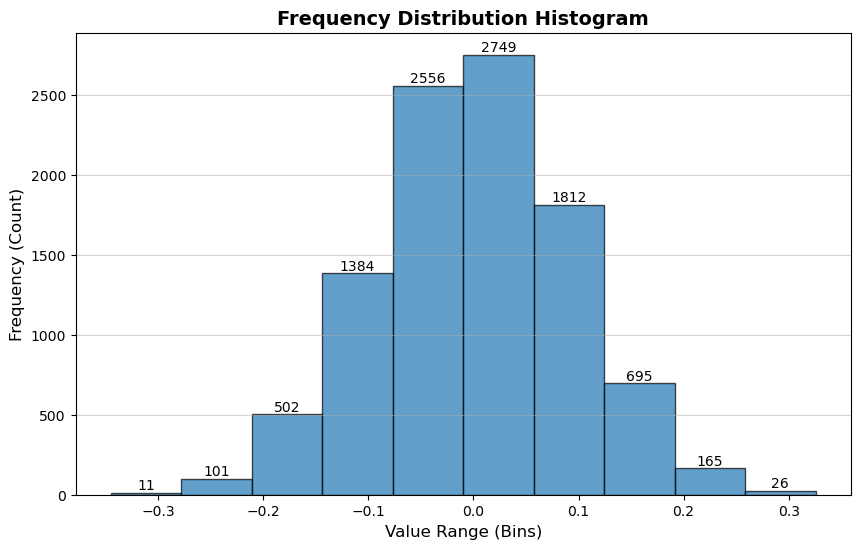

In [171]:
data = part_corrs.loc['codon_freqs_avg_0','K562_rand']
plt.figure(figsize=(10, 6)) # Creates a figure and sets its size
n, bins, patches = plt.hist(
    data,
    bins=10,  # You can adjust the number of bins
    color='#1f77b4', # A nice blue color
    edgecolor='black',
    alpha=0.7
)

# --- Customizing the Plot (Best Practices) ---

# Set labels for the axes
plt.xlabel("Value Range (Bins)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)

# Set the title of the histogram
plt.title("Frequency Distribution Histogram", fontsize=14, fontweight='bold')

# Add a grid for easier reading of counts
plt.grid(axis='y', alpha=0.5)

# Optional: Display the exact count on top of each bar
for i in range(len(n)):
    plt.text(
        (bins[i] + bins[i+1]) / 2, # x-coordinate (center of the bar)
        n[i] + 0.5,                # y-coordinate (slightly above the bar)
        str(int(n[i])),            # The count value
        ha='center',
        va='bottom'
    )

# Ensure the plot is displayed
plt.show()

In [154]:
q=real_sig_01.iloc[0,0]
aa

In [177]:
real_sig_01.to_csv('part_real_sig_01_df.csv')

In [131]:
fdrs_df.to_csv('fdrs_partial_corrs.csv')

In [569]:
all_models_df = pd.DataFrame(columns=concised_names, index= ['rand_forest','xgb','linear'])
for df_name in df_names:
    for model_name in ['linear','xgb','rand_forest']:
        fold = f'/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/13_11_25_results/{model_name}/'
        df = pd.read_csv(fold+df_name.split('_')[0]+f'_public_{model_name}.csv')
        all_models_df.loc[model_name,df_name.split('_')[0]] = f'{df["Unnamed: 0"].iloc[0].replace("_eff","")} {df.r.iloc[0]:.2f}'

all_models_df.to_csv('all_models_public_results_13_11_25.csv')

In [570]:
all_models_df

,T,ICS,K562,U937,Fly,Shrimp-primary,Tomato-Protoplasts,Tomato-hairy-roots
rand_forest,"DeepCRISPR, uCRISPR 0.32","uCRISPR, SPROUT 0.08","uCRISPR, SPROUT 0.24",uCRISPR 0.17,"DeepCRISPR, uCRISPR 0.28","CRISPRedict, uCRISPR 0.38",CRISPRedict 0.18,CRISPRedict 0.04
xgb,"CRISPRedict, DeepCRISPR, uCRISPR, SPROUT 0.27","CRISPRedict, uCRISPR 0.10","DeepCRISPR, uCRISPR, SPROUT 0.26","CRISPRedict, DeepCRISPR 0.08",uCRISPR 0.25,"CRISPRedict, uCRISPR, SPROUT 0.23","CRISPRedict, uCRISPR 0.20",CRISPRedict 0.13
linear,"uCRISPR, SPROUT 0.39","DeepCRISPR, SPROUT 0.14","CRISPRedict, uCRISPR 0.30",CRISPRedict 0.23,uCRISPR 0.25,uCRISPR 0.33,uCRISPR 0.22,DeepCRISPR 0.06


['uCRISPR', 'SPROUT']

In [538]:
for df_name in df_names:
    df = read_df(df_name)    
    print(f'-----------------------{df_name}--------------------------')
    if df_name == 'Tomato-hairy-roots_eff.csv':
        editing_efficiency = 'editing_efficiency'
    else:
        editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
    target_col = editing_efficiency
    X = df[[x for x in df.columns if x!=editing_efficiency]]
    X = X.astype(float)
    y = df[editing_efficiency]
    if not isinstance(y, pd.Series):
        y = pd.Series(y).reset_index(drop=True)
    just_feat_raw_results = {x:[] for x in X.columns.tolist()}
    for rand_i in range(100):
        _, X_test, _, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=rand_i,
        shuffle=True )
        for col in X_test.columns:
            corr, p = spearmanr(X_test[col], y_test)
            just_feat_raw_results[col].append(corr)
    just_feat_results = {x:np.nanmedian(just_feat_raw_results[x]) for x in just_feat_raw_results.keys()}
    res_df = pd.DataFrame.from_dict(just_feat_results, orient='index', columns=['r'])
    res_df = res_df.reindex(res_df['r'].abs().sort_values(ascending=False).index)
    print(res_df.head())
print('done')

-----------------------T_w_reads_w2_w8.csv--------------------------


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/4033701203.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(X_test[col], y_test)


                                        r
SPROUT_eff                          0.356
uCRISPR_eff                         0.300
local_sites_count_ngg_pam_10000_-0 -0.244
guide&scafEne                       0.201
sites_count_ngg_pam_genome_-10_d2   0.184
-----------------------ICS_w_reads_w2_w8.csv--------------------------


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/4033701203.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(X_test[col], y_test)


                                       r
sites_count_ngg_pam_genome_-10_d5  0.266
isBasePairs                        0.189
SPROUT_eff                         0.153
DNAshape_HelT_mean                 0.152
local_sites_count_1000_-5         -0.137
-----------------------K562_w_reads_w2_w8.csv--------------------------


...

                                       r
uCRISPR_eff                        0.332
SPROUT_eff                         0.233
local_sites_count_10000_-5        -0.212
DeepCRISPR_eff                     0.208
local_sites_count_ngg_pam_1000_-0 -0.205
-----------------------Tomato-Protoplasts_w_reads_w2_w8.csv--------------------------


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/4033701203.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(X_test[col], y_test)


                               r
CAI_avg_0                  0.227
uCRISPR_eff                0.216
local_sites_count_1000_-5 -0.209
codon_freqs_avg_0          0.207
Head3                      0.204
-----------------------Tomato-hairy-roots_eff.csv--------------------------


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/4033701203.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(X_test[col], y_test)


                                       r
DNAshape_HelT_mean                -0.240
guideEne                          -0.173
sites_count_ngg_pam_genome_-10_d2  0.163
local_sites_count_100000_-5        0.150
isBasePairs                        0.148
done


In [535]:
for df_name in df_names:
    df = read_df(df_name)    
    print(f'-----------------------{df_name}--------------------------')

    if df_name == 'Tomato-hairy-roots_eff.csv':
        editing_efficiency = 'editing_efficiency'
    else:
        editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
    target_col = editing_efficiency

    results = []
    for col in df.columns:
        if col != target_col:
            valid = df[[target_col, col]].dropna()
            if len(valid) > 1:
                corr, p = spearmanr(valid[target_col], valid[col])
                results.append((col, corr, p))
    
    corr_df = pd.DataFrame(results, columns=['column', 'spearman_corr', 'p_value'])
    
    # sort by correlation strength
    corr_sorted_by_corr = corr_df.reindex(corr_df['spearman_corr'].abs().sort_values(ascending=False).index).copy()
    
    # or by significance
    corr_sorted_by_p = corr_df.sort_values(by='p_value', ascending=True).copy()
    
    # print("Sorted by |correlation|:")
    # print(corr_sorted_by_corr.head())
    
    print("\nSorted by p-value:")
    print(corr_sorted_by_p.head())
    # print(corr_df.head())
    
print('done')

-----------------------T_w_reads_w2_w8.csv--------------------------

Sorted by p-value:
                                column  spearman_corr    p_value
32                          SPROUT_eff          0.349  8.717e-05
31                         uCRISPR_eff          0.307  6.023e-04
3                        guide&scafEne          0.222  1.422e-02
18  local_sites_count_ngg_pam_10000_-0         -0.217  1.677e-02
20           local_sites_count_1000_-5          0.182  4.536e-02
-----------------------ICS_w_reads_w2_w8.csv--------------------------

Sorted by p-value:
                               column  spearman_corr    p_value
30  sites_count_ngg_pam_genome_-10_d5          0.243  7.881e-04
8                         isBasePairs          0.155  3.366e-02
20  local_sites_count_ngg_pam_1000_-0         -0.154  3.562e-02
16                 DNAshape_HelT_mean          0.150  3.994e-02
21  local_sites_count_ngg_pam_1000_-5         -0.139  5.761e-02
-----------------------K562_w_reads_w2_w8.csv-

In [23]:
import pandas as pd
import numpy as np

def convert_columns_to_float(df, threshold=0.5):
    """
    Convert DataFrame columns to floats.
    
    Parameters:
    - df: pandas DataFrame
    - threshold: fraction of "weird" values allowed before warning
    
    Returns:
    - new_df: DataFrame with converted columns
    """
    new_df = df.copy()
    
    for col in df.columns:
        converted = []
        weird_count = 0
        
        for v in df[col]:
            try:
                f = float(v)
                converted.append(f)
            except (ValueError, TypeError):
                weird_count += 1
                # replace with mean so far, or 0 if none yet
                if converted:
                    converted.append(np.mean(converted))
                else:
                    converted.append(0.0)
        
        new_df[col] = converted
        
        # Warn if too many weird values
        if weird_count / len(df[col]) > threshold:
            print(f"Warning: Column '{col}' has {weird_count} weird values ({weird_count/len(df[col]):.1%})")
    
    return new_df


In [316]:
def adjusted_spearman_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_true = np.ravel(y)
    r = spearmanr(y_true, y_pred)[0]
    if np.isnan(r):
        return -1e6
    n = len(y_true)
    p = X.shape[1]
    r2 = r ** 2
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(1, (n - p - 1))
    adj_r = np.sign(r) * np.sqrt(max(0, adj_r2))
    return adj_r

In [607]:
def set_model(model_name):
    if model_name=='linear':
        model = LinearRegression()
    elif model_name=='rand_forest':
        model = RandomForestRegressor(
        n_estimators=100,        # modest number of trees
        max_depth=3,             # shallow trees to prevent overfitting
        min_samples_split=5,
        min_samples_leaf=2,
        max_features=None,       # with 4 feats, let all be considered
        random_state=0
        )
        # model = RandomForestRegressor(
        #         n_estimators=300,
        #         max_depth=3,
        #         min_samples_split=3,
        #         min_samples_leaf=2,
        #         max_features=None,
        #         random_state=42
        #     )
         # model = RandomForestRegressor()
    elif model_name == 'xgb':
            # model =  XGBRegressor()
          model =  XGBRegressor(
                n_estimators=200,        # more trees but each contributes little
                learning_rate=0.05,      # slow learning to prevent overfitting
                max_depth=2,             # shallow trees
                subsample=0.8,           # add randomness
                colsample_bytree=0.8,
                reg_lambda=1.0,          # L2 regularization
                reg_alpha=0.0,           # L1 regularization (set >0 if you want stronger shrinkage)
                random_state=0,
                n_jobs=-1
            )
    return model

In [333]:
import warnings
def adjusted_spearman(y_pred, y_true, n_samples, m_features,features):
    r = spearmanr(y_true, y_pred)[0]
    # with warnings.catch_warnings(record=True) as w:
    #     warnings.simplefilter("always")  # make sure all warnings are captured
    #     r = spearmanr(y_true, y_pred)[0]
    
    #     for warn in w:
    #         if issubclass(warn.category, RuntimeWarning) and "ConstantInputWarning" in str(warn.message):
    #             print("⚠️ Spearman warning: one of the inputs is constant after filtering.")
    #             print(y_true)
    #             print(y_pred)
    #             print(features)
            
    if np.isnan(r):
        return -1e6
    n = len(y_true)
    r2 = r ** 2
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / max(1, (n_samples - m_features - 1))
    adj_r = np.sign(r) * np.sqrt(max(0, adj_r2))
    return adj_r

In [334]:
a=1

In [638]:
def forward_feature_selection_no_cv_N_feats(model_name, X_in_func, y_in_func, rand_i=0, N_feats=10, starting_feats=[], verbose=False, do_valid=False):
    if verbose:
        print(f'--------------------------------- round {rand_i} ---------------------------------')
    feat_names = list(X_in_func.columns)
    if not isinstance(y_in_func, pd.Series):
        y_in_func = pd.Series(y_in_func).reset_index(drop=True)
    model = set_model(model_name)
    remaining_feats = feat_names.copy()
    remaining_feats = [x for x in remaining_feats if x not in starting_feats]
    # print(starting_feats)
    selected_feats = starting_feats
    best_score = -np.inf
    step = 1
    X_train, X_test, y_train, y_test = train_test_split(
        X_in_func, y_in_func,
        test_size=0.2,
        random_state=rand_i,
        shuffle=True
    )       
    # for s in [X_train, X_test, y_train, y_test]:
    #     print(len(s))

    all_ys_train_real = []
    all_ys_train_pred = []
    
    if len(feat_names)==1:
        selected_feats=feat_names
    else:
        while remaining_feats and len(selected_feats)<N_feats:
            scores = []
            if verbose:
                print(f"\n=== Step {step}: testing additions to {selected_feats or '[]'} ===")
    
            for feat in remaining_feats:
                if len(set(X_train[feat]))==1:
                    continue
                feats_to_try = selected_feats + [feat]
                if do_valid:
                    X_train_train, X_train_valid, y_train_train, y_train_valid = train_test_split(
                        X_train, y_train,
                        test_size=0.25,
                        random_state=rand_i,
                        shuffle=True
                    )       
     
                    model.fit(X_train_train[feats_to_try], y_train_train)
                    y_pred = model.predict(X_train_valid[feats_to_try])
                    r = adjusted_spearman(y_pred, y_train_valid, X_train_valid.shape[0], len(feats_to_try),feats_to_try)
                else:
                    model.fit(X_train[feats_to_try], y_train)
                    y_pred = model.predict(X_train[feats_to_try])
                    y_pred = np.array(y_pred)
                    y_train = np.array(y_train)
                    r = adjusted_spearman(y_pred, y_train, X_train.shape[0], len(feats_to_try),feats_to_try)
                    all_ys_train_real.append(y_train)
                    all_ys_train_pred.append(y_pred)

                    # print(y_pred)
                    # print(y_train)
                scores.append([r,feat])
            best_feat_score, best_feat  = max(scores, key=lambda x: x[0])
            if verbose:
                print(f"Best new feat: {best_feat} (Adjusted R Spearman {best_feat_score:.3f})")
                # print(f"# of feats: {len(feats_to_try)} (Adjusted R Spearman {best_feat_score:.3f})")
    
            # Stop if no improvement
            if best_feat_score <= best_score:
                if verbose:
                    print("No improvement — stopping.")
                break
    
            selected_feats.append(best_feat)
            remaining_feats.remove(best_feat)
            best_score = best_feat_score
            step += 1

    if verbose:
        print(f"\n✅ Final selected features: {selected_feats}")
        print(f"✅ Adjusted R Spearman: {best_score:.3f}")

    final_model = model.fit(X_train[selected_feats], y_train)
    y_test_pred = model.predict(X_test[selected_feats])

    r = spearmanr(y_test, y_test_pred)[0]
    # print(f"✅ Spearman: {r:.3f}")

    return selected_feats, r, scores, all_ys_train_real, all_ys_train_pred


In [ ]:
results = {x.split('_')[0]:{} for x in df_names}
    
from time import time
a=time()
a_df = pd.read_csv('all_models_public_results_13_11_25.csv')
a_df.index = a_df['Unnamed: 0'].values
a_df=a_df.drop(columns=['Unnamed: 0'])
for the_model_name in ['linear','rand_forest','xgb']:
    with open("error_log.txt", "a") as f:
        f.write(f'{the_model_name}')
    print(the_model_name)
    try:
        for df_name in df_names:
            print(df_name)
            concised_name = df_name.split('_')[0]
            df = pd.read_csv(df_name)
            if df_name == 'Tomato-hairy-roots_eff.csv':
                editing_efficiency = 'editing_efficiency'
            else:
                editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
            
            df = make_rep_feats(df, editing_efficiency)
            df = df[~df[editing_efficiency].isna()]
            df = df.dropna(axis=1, how='all')
            nonfloat_cols = []
            constant_cols = []
            for col in df.columns:
                # Check if column can be converted to float
                try:
                    df[col].astype(float)
                except (ValueError, TypeError):
                    nonfloat_cols.append(col)
                    continue  # no need to check if constant
                # Check if column has only one unique value (ignoring NaN)
                unique_vals = df[col].dropna().unique()
                if len(unique_vals) <= 1:
                    constant_cols.append(col)
            cols_to_drop = list(set(constant_cols+nonfloat_cols))
            df = df.drop(columns=cols_to_drop)  
            # Identify columns with NaN values
            cols_with_nan = df.columns[df.isna().any()].tolist()
            # Loop through each column that has NaNs and fill NaNs with the column's mean
            for col in cols_with_nan:
                # Calculate the mean of the current column
                mean_value = df[col].mean()
            
                # Fill NaN values in the current column with its calculated mean
                df[col] = df[col].fillna(mean_value)
            # print(f"NaN values in the following columns were filled with their respective means: {cols_with_nan}")
            
            X = df[[x for x in df.columns if x!=editing_efficiency]]
            X = X.astype(float)
            y = df[editing_efficiency]
            scores = []
            selected_feats = []
            r_from_train_scores = []
            all_ys_train_real, all_ys_train_pred = [], []

            idx = a_df.loc[the_model_name,concised_name].index('0')
            feats_to_start = a_df.loc[the_model_name,concised_name][:idx].replace(' ','').split(',')
            feats_to_start = [x+'_eff' for x in feats_to_start]
            # print(the_model_name, concised_name, feats_to_start)
            for rand_i in range(10):
                # if rand_i%10==0: print('here',rand_i, feats_to_start)
                curr_selected_feats, curr_score, curr_r_from_train_scores, curr_all_ys_train_real, curr_all_ys_train_pred = \
                forward_feature_selection_no_cv_N_feats(the_model_name, X, y, rand_i, 5, feats_to_start.copy(), do_valid=True) 
                # forward_feature_selection_no_cv(the_model_name, X, y, rand_i, verbose=False) 
                scores.append(curr_score)
                selected_feats.append(curr_selected_feats)
                r_from_train_scores.append(curr_r_from_train_scores)
                all_ys_train_real.append(curr_all_ys_train_real)
                all_ys_train_pred.append(curr_all_ys_train_pred)
            results[concised_name][the_model_name] = [np.nanmedian(scores), scores, selected_feats, r_from_train_scores, all_ys_train_real, all_ys_train_pred]
            with open("regressor_13_11_25_w_best_public_w_maagad_feats_results.pkl", "wb") as f:
                pickle.dump(results, f)
            print(concised_name, the_model_name, np.nanmedian(scores))
            lists = results[concised_name][the_model_name][2]
            counter = Counter()
            for sublist in lists:
                counter.update(set(sublist))  # use set() to avoid double-counting duplicates within the same list
            
            threshold = 0.7 * len(lists)
            common_elements = [elem for elem, count in counter.items() if count >= threshold]
            print(common_elements)
            # break
    except Exception as e:
        # Open (or create) a file to save the error
        with open("error_log.txt", "a") as f:
            f.write(f"{the_model_name} {concised_name}:\n\n")
            f.write("An error occurred:\n\n")
            # Write the error message
            f.write(str(e) + "\n\n")
            # Write the full traceback for debugging
            f.write("Full traceback:\n")
            f.write(traceback.format_exc())
        print(the_model_name,concised_name,'error')
        continue
        
    print("done")
    # break
with open("error_log.txt", "a") as f:
    f.write(f'{time()-a}')

print(time()-a)
print("all done")

linear
T_w_reads_w2_w8.csv
T linear 0.27730769230769226
['SPROUT_eff', 'uCRISPR_eff']
ICS_w_reads_w2_w8.csv
ICS linear 0.06412080096290622
['DeepCRISPR_eff', 'SPROUT_eff']
K562_w_reads_w2_w8.csv
K562 linear 0.33576923076923076
['CRISPRedict_eff', 'DeepCRISPR_eff', 'uCRISPR_eff']
U937_w_reads_w2_w8.csv
U937 linear 0.16433566433566438
['CRISPRedict_eff']
Fly_w_reads_w2_w8.csv
Fly linear 0.21624649859943978
['uCRISPR_eff']
Shrimp-primary_w_reads_w2_w8.csv
Shrimp-primary linear 0.18947368421052635
['uCRISPR_eff']
Tomato-Protoplasts_w_reads_w2_w8.csv
Tomato-Protoplasts linear 0.20556173526140153
['uCRISPR_eff']
Tomato-hairy-roots_eff.csv


In [643]:
a_df

,T,ICS,K562,U937,Fly,Shrimp-primary,Tomato-Protoplasts,Tomato-hairy-roots
rand_forest,"DeepCRISPR, uCRISPR 0.32","uCRISPR, SPROUT 0.08","uCRISPR, SPROUT 0.24",uCRISPR 0.17,"DeepCRISPR, uCRISPR 0.28","CRISPRedict, uCRISPR 0.38",CRISPRedict 0.18,CRISPRedict 0.04
xgb,"CRISPRedict, DeepCRISPR, uCRISPR, SPROUT 0.27","CRISPRedict, uCRISPR 0.10","DeepCRISPR, uCRISPR, SPROUT 0.26","CRISPRedict, DeepCRISPR 0.08",uCRISPR 0.25,"CRISPRedict, uCRISPR, SPROUT 0.23","CRISPRedict, uCRISPR 0.20",CRISPRedict 0.13
linear,"uCRISPR, SPROUT 0.39","DeepCRISPR, SPROUT 0.14","CRISPRedict, uCRISPR 0.30",CRISPRedict 0.23,uCRISPR 0.25,uCRISPR 0.33,uCRISPR 0.22,DeepCRISPR 0.06


In [665]:
lists = results['T']['linear'][2]
counter = Counter()
for sublist in lists:
    counter.update(set(sublist))  # use set() to avoid double-counting duplicates within the same list

threshold = 0.7 * len(lists)
common_elements = [elem for elem, count in counter.items() if count >= threshold]

print(common_elements)

['SPROUT_eff', 'uCRISPR_eff']


In [631]:
def forward_feature_selection_no_cv(model_name, X_in_func, y_in_func, rand_i=0, verbose=False, do_valid=False):
    """
    Forward feature selection using internal cross-validation.
    Reduces overfitting to a single validation split.
    """
    if verbose:
        print(f'--------------------------------- round {rand_i} ---------------------------------')
    feat_names = list(X_in_func.columns)
    if not isinstance(y_in_func, pd.Series):
        y_in_func = pd.Series(y_in_func).reset_index(drop=True)
    model = set_model(model_name)
    remaining_feats = feat_names.copy()
    selected_feats = []
    best_score = -np.inf
    step = 1
    X_train, X_test, y_train, y_test = train_test_split(
        X_in_func, y_in_func,
        test_size=0.2,
        random_state=rand_i,
        shuffle=True
    )       
    # for s in [X_train, X_test, y_train, y_test]:
    #     print(len(s))

    all_ys_train_real = []
    all_ys_train_pred = []
    
    if len(feat_names)==1:
        selected_feats=feat_names
    else:
        while remaining_feats:
            scores = []
            if verbose:
                print(f"\n=== Step {step}: testing additions to {selected_feats or '[]'} ===")
    
            for feat in remaining_feats:
                if len(set(X_train[feat]))==1:
                    continue
                feats_to_try = selected_feats + [feat]
                if do_valid:
                    X_train_train, X_train_valid, y_train_train, y_train_valid = train_test_split(
                        X_train, y_train,
                        test_size=0.25,
                        random_state=rand_i,
                        shuffle=True
                    )       
     
                    model.fit(X_train_train[feats_to_try], y_train_train)
                    y_pred = model.predict(X_train_valid[feats_to_try])
                    r = adjusted_spearman(y_pred, y_train_valid, X_train_valid.shape[0], len(feats_to_try),feats_to_try)
                else:
                    model.fit(X_train[feats_to_try], y_train)
                    y_pred = model.predict(X_train[feats_to_try])
                    y_pred = np.array(y_pred)
                    y_train = np.array(y_train)
                    r = adjusted_spearman(y_pred, y_train, X_train.shape[0], len(feats_to_try),feats_to_try)
                    all_ys_train_real.append(y_train)
                    all_ys_train_pred.append(y_pred)

                    # print(y_pred)
                    # print(y_train)
                scores.append([r,feat])
            best_feat_score, best_feat  = max(scores, key=lambda x: x[0])
            if verbose:
                print(f"Best new feat: {best_feat} (Adjusted R Spearman {best_feat_score:.3f})")
                # print(f"# of feats: {len(feats_to_try)} (Adjusted R Spearman {best_feat_score:.3f})")
    
            # Stop if no improvement
            if best_feat_score <= best_score:
                if verbose:
                    print("No improvement — stopping.")
                break
    
            selected_feats.append(best_feat)
            remaining_feats.remove(best_feat)
            best_score = best_feat_score
            step += 1

    if verbose:
        print(f"\n✅ Final selected features: {selected_feats}")
        print(f"✅ Adjusted R Spearman: {best_score:.3f}")

    final_model = model.fit(X_train[selected_feats], y_train)
    y_test_pred = model.predict(X_test[selected_feats])

    r = spearmanr(y_test, y_test_pred)[0]
    # print(f"✅ Spearman: {r:.3f}")

    return selected_feats, r, scores, all_ys_train_real, all_ys_train_pred


In [466]:
results['T'].keys()

dict_keys(['linear', 'rand_forest', 'xgb'])

In [ ]:
wtfmate

In [440]:

for y_reals,y_preds in zip(results['T']['linear'][4],results['T']['linear'][5]):
    # print(y_real)
    print('---------------')
    # print(y_pred)
    count=0
    for y_r,y_p in zip(y_reals,y_preds):
        print(count,spearmanr(y_r,y_p))
        count+=1
        # break
    break

---------------
0 SignificanceResult(statistic=np.float64(0.12559049644163522), pvalue=np.float64(0.22275107454542672))
1 SignificanceResult(statistic=np.float64(0.09287877400614315), pvalue=np.float64(0.36809410925556885))
2 SignificanceResult(statistic=np.float64(0.07904813853713309), pvalue=np.float64(0.44393591024075174))
3 SignificanceResult(statistic=np.float64(0.24993471114849392), pvalue=np.float64(0.014053932460740888))
4 SignificanceResult(statistic=nan, pvalue=nan)
5 SignificanceResult(statistic=np.float64(0.09593287731241298), pvalue=np.float64(0.35248484424561644))
6 SignificanceResult(statistic=np.float64(-0.004843734104796958), pvalue=np.float64(0.962642908901153))
7 SignificanceResult(statistic=np.float64(0.10715073737912333), pvalue=np.float64(0.298757768457509))
8 SignificanceResult(statistic=np.float64(0.01622443454344473), pvalue=np.float64(0.875328174224945))
9 SignificanceResult(statistic=np.float64(0.10029334465197634), pvalue=np.float64(0.3309253324042468))
10 S

/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/3764355736.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  print(count,spearmanr(y_r,y_p))


In [437]:
y_real[0]

[array([6.76636154e+01, 5.67855845e+01, 5.09747950e+01, 7.36406660e+01,
        5.52005217e+01, 4.11367909e+01, 5.61115524e+01, 6.39097210e+01,
        4.50841622e+01, 3.80591196e+01, 7.89028630e+01, 2.95448410e+01,
        4.36309243e+01, 5.29855868e+01, 5.91903627e+01, 9.75164236e+01,
        6.00951038e+01, 7.92696139e+01, 4.26205313e+01, 5.23032694e+01,
        6.05921723e+01, 5.96037447e+01, 1.52529662e+01, 6.40897510e+01,
        4.12743273e+01, 2.30267357e+01, 6.64955644e+01, 8.29322217e+01,
        8.02511360e+01, 4.05457416e+01, 9.99614495e+01, 4.74456911e+01,
        6.04867331e+01, 3.75410720e+01, 4.49681490e+01, 6.22517700e+01,
        6.36538461e+01, 4.73780608e+01, 6.00132157e+01, 3.83368928e+01,
        6.66052922e+01, 6.73335454e+01, 4.67306928e+01, 9.97700964e+01,
        2.51614946e+01, 6.21403844e+01, 6.13000835e+01, 3.85260747e+01,
        4.82742184e+01, 4.51032843e+01, 4.28377507e+01, 5.72232645e+01,
        5.85806578e+01, 7.02467039e+01, 2.30586916e+01, 3.923128

In [460]:
a1 = results['T']['linear'][4][0][4]
a2 = results['T']['linear'][5][0][4]
spearmanr(a1,a2)

/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/2678248163.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearmanr(a1,a2)


SignificanceResult(statistic=nan, pvalue=nan)

In [459]:
vec1 = np.asarray(a1)
vec2 = np.asarray(a2)
from scipy.stats import rankdata

rankdata(vec1, method='average')

array([74., 44., 35., 83., 40., 16., 41., 65., 25.,  9., 86.,  7., 22.,
       39., 52., 92., 55., 87., 18., 38., 57., 53.,  3., 68., 17.,  4.,
       71., 90., 89., 14., 96., 30., 56.,  8., 24., 61., 64., 29., 54.,
       10., 72., 73., 28., 94.,  6., 60., 59., 11., 31., 26., 19., 45.,
       50., 80.,  5., 12., 43., 32., 84., 36., 79., 62., 13., 67., 46.,
       78., 85., 27., 48., 42., 66., 69., 34., 20., 81., 51., 37., 77.,
       93., 49., 15., 21., 58.,  1., 95., 91., 63., 70., 82., 76.,  2.,
       23., 75., 47., 33., 88.])

In [451]:
a2

array([56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736735,
       56.9736735, 56.9736735, 56.9736735, 56.9736735, 56.9736

In [ ]:
results['T']['linear'][5][0][4]

In [456]:
results['T']['linear'][2][4]

['SPROUT_eff',
 'local_sites_count_ngg_pam_10000_-0',
 'local_sites_count_ngg_pam_1000_-5',
 'Head2',
 'guide&scafEne',
 'CRISPRedict_eff',
 'Head3']

In [478]:
results['ICS']['linear'][0]

np.float64(0.09990152095415253)

In [485]:
all_results_df = pd.DataFrame({'linear':['']*8, 'rand_forest':['']*8,'xgb':['']*8})
all_results_df.index = list(results.keys())
for model_name in ['linear', 'rand_forest', 'xgb']:
    for k in results.keys():
        all_results_df.loc[k,model_name] = results[k][model_name][0]

In [486]:
all_results_df

,linear,rand_forest,xgb
T,0.331,0.084,0.016
ICS,0.1,0.051,0.051
K562,0.353,0.285,0.189
U937,0.066,0.091,0.061
Fly,0.096,0.063,0.035
Shrimp-primary,0.158,0.285,0.076
Tomato-Protoplasts,0.183,0.076,0.132
Tomato-hairy-roots,0.118,0.07,0.032


['chimera_avg_0']


In [468]:
import pickle

with open("regressor_11_11_25_w_maagad_feats_results.pkl", "wb") as f:
    pickle.dump(results, f)


In [404]:
print('aaa')

aaa


In [359]:
results_train = results.copy()

In [360]:
results_train.keys()

dict_keys(['T', 'ICS', 'K562', 'U937', 'Fly', 'Shrimp-primary', 'Tomato-Protoplasts', 'Tomato-hairy-roots'])

In [379]:
spearmanr([1,1,1,1,1.000000000000001],[2,3,4,5,6])[0]

np.float64(0.7071067811865475)

In [222]:
def forward_feature_selection_with_cv(model_name, X_in_func, y_in_func, n_splits=5, random_state=42, verbose=False):
    """
    Forward feature selection using internal cross-validation.
    Reduces overfitting to a single validation split.
    """
    if hasattr(X_in_func, "columns"):
        feat_names = list(X_in_func.columns)
    else:
        feat_names = [f"feat_{i}" for i in range(X_in_func.shape[1])]
        X_in_func = pd.DataFrame(X_in_func, columns=feat_names)

    if not isinstance(y_in_func, pd.Series):
        y_in_func = pd.Series(y_in_func).reset_index(drop=True)
    
    model = set_model(model_name)
    remaining_feats = feat_names.copy()
    selected_feats = []
    best_score = -np.inf
    rng = np.random.RandomState(random_state)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    # print(remaining_feats)
    step = 1
    if len(feat_names)==1:
        selected_feats=feat_names
    else:
        while remaining_feats:
            scores = []
            if verbose:
                print(f"\n=== Step {step}: testing additions to {selected_feats or '[]'} ===")
    
            for feat in remaining_feats:
                feats_to_try = selected_feats + [feat]
                fold_scores = []
    
                # Cross-validation for this feature subset
                for train_idx, val_idx in kf.split(X_in_func):
                    X_train, X_val = X_in_func.iloc[train_idx][feats_to_try], X_in_func.iloc[val_idx][feats_to_try]
                    y_train, y_val = y_in_func.iloc[train_idx], y_in_func.iloc[val_idx]
                    model.fit(X_train, y_train)
                    preds = model.predict(X_val)
                    fold_scores.append(spearmanr(y_val, preds)[0])
    
                mean_score = np.nanmedian(fold_scores)
                scores.append((feat, mean_score))
                if verbose:
                    print(f"  Try {feats_to_try}: median CV Spearman = {mean_score:.3f}")
    
            best_feat, best_feat_score = max(scores, key=lambda x: x[1])
            if verbose:
                print(f"Best new feat: {best_feat} (median CV Spearman {best_feat_score:.3f})")
    
            # Stop if no improvement
            if best_feat_score <= best_score:
                if verbose:
                    print("No improvement — stopping.")
                break
    
            selected_feats.append(best_feat)
            remaining_feats.remove(best_feat)
            best_score = best_feat_score
            step += 1

    if verbose:
        print(f"\n✅ Final selected features: {selected_feats}")
        print(f"✅ Best median CV Spearman: {best_score:.3f}")

    # Fit final model on *all training data* using selected features
    final_model = set_model(model_name)
    final_model.fit(X_in_func[selected_feats], y_in_func)

    return final_model, selected_feats


In [233]:
def run_forward_feature_selection(X_train, y_train, model_name, random_state=0):
    """
    Runs forward feature selection with CV using Spearman correlation.
    Works even if y_train is a numpy array.
    Returns: selected feature names (list)
    """

    # Ensure y_train is pandas Series for compatibility
    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train, index=X_train.index)

    if X_train.shape[1]!=1:
        # Define CV
        kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    
        # Define Sequential Feature Selector
        sfs = SequentialFeatureSelector(
            estimator=set_model(model_name),
            n_features_to_select="auto",  # auto-stops when CV score stops improving
            direction='forward',
            scoring=adjusted_spearman_scorer,
            cv=kf,
            n_jobs=-1
        )
    
        # Fit selector
        sfs.fit(X_train, y_train)
    
        # Get selected feature names
        selected_feats = list(X_train.columns[sfs.get_support()])
    else:
        selected_feats = X_train.columns.to_list()
    
    # final_model = set_model(model_name)
    # final_model.fit(X_train[selected_feats], y_train)
    scores = []
    for rand_i in range(20):
        kf = KFold(n_splits=5, shuffle=True, random_state=rand_i)
        for i, (train_idx, test_idx) in enumerate(kf.split(df[selected_feats])):
            # print(X_train.shape, X_train.iloc[test_idx][selected_feats], X_train.iloc[test_idx][selected_feats].columns)
            X_train_cv, X_test_cv = X_train.iloc[train_idx][selected_feats], X_train.iloc[test_idx][selected_feats]
            y_train_cv, y_test_cv = y_train.iloc[train_idx], y_train.iloc[test_idx]
        
            model = clone(sfs.estimator)
            model.fit(X_train_cv, y_train_cv)
            y_pred = model.predict(X_test_cv)
        
            rho = spearmanr(y_test_cv, y_pred)[0]
            # rho = adjusted_spearman_func(y_test, y_pred)
            scores.append(rho)
    # print(np.median(scores))
    
    return selected_feats, sfs, scores

In [234]:
results = {x.split('_')[0]:{} for x in df_names}
    
from time import time
a=time()
for the_model_name in ['linear','rand_forest','xgb']:
    with open("error_log.txt", "a") as f:
        f.write(f'{the_model_name}')
    print(the_model_name)
    try:
        final_summary_df = pd.DataFrame()   # start empty
        final_results_df = pd.DataFrame()   # start empty
        raw_cols = ['selected_feats',	'RAND_selected_feats','median_real'	,'median_perm']
        folder= f"./9_11_25_results/{the_model_name}/"
        for df_name in df_names:
            print(df_name)
            concised_name = df_name.split('_')[0]
            df = pd.read_csv(df_name)
            editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
            df = make_rep_feats(df, editing_efficiency)
            df = df[~df[editing_efficiency].isna()]
            df = df.dropna(axis=1, how='all')
            nonfloat_cols = []
            constant_cols = []
            
            for col in df.columns:
                # Check if column can be converted to float
                try:
                    df[col].astype(float)
                except (ValueError, TypeError):
                    nonfloat_cols.append(col)
                    continue  # no need to check if constant
            
                # Check if column has only one unique value (ignoring NaN)
                unique_vals = df[col].dropna().unique()
                if len(unique_vals) <= 1:
                    constant_cols.append(col)
            cols_to_drop = list(set(constant_cols+nonfloat_cols))
            # print(cols_to_drop)
            df = df.drop(columns=cols_to_drop)  
            # Identify columns with NaN values
            cols_with_nan = df.columns[df.isna().any()].tolist()
            
            # Loop through each column that has NaNs and fill NaNs with the column's mean
            for col in cols_with_nan:
                # Calculate the mean of the current column
                mean_value = df[col].mean()
            
                # Fill NaN values in the current column with its calculated mean
                df[col].fillna(mean_value, inplace=True)
    
            print(f"NaN values in the following columns were filled with their respective means: {cols_with_nan}")
            selected_feats, sfs, scores = run_forward_feature_selection(df[[x for x in df.columns if x!=editing_efficiency]],
                                                                                     df[editing_efficiency],
                                                                                     the_model_name, random_state=0)  
            results[concised_name][the_model_name] = [np.median(scores), scores, selected_feats]
            print(concised_name, the_model_name, np.median(scores))
    except Exception as e:
        # Open (or create) a file to save the error
        with open("error_log.txt", "a") as f:
            f.write(f"{the_model_name} {concised_name}:\n\n")
            f.write("An error occurred:\n\n")
            # Write the error message
            f.write(str(e) + "\n\n")
            # Write the full traceback for debugging
            f.write("Full traceback:\n")
            f.write(traceback.format_exc())
        print(the_model_name,concised_name,'error')
        continue
        # break
    print("done")
    # break
print("all done")
print(time()-a)
with open("error_log.txt", "a") as f:
    f.write(f'{time()-a}')

linear
T_w_reads_w2_w8.csv
NaN values in the following columns were filled with their respective means: ['DNAshape_MGW_mean', 'DNAshape_ProT_mean', 'DNAshape_Roll_mean', 'DNAshape_HelT_mean', 'enthalpy_mean', 'local_sites_count_ngg_pam_1000_-0', 'local_sites_count_ngg_pam_1000_-5', 'local_sites_count_ngg_pam_10000_-0', 'local_sites_count_ngg_pam_10000_-5', 'local_sites_count_1000_-5', 'local_sites_count_10000_-5', 'local_sites_count_ngg_pam_100000_-0', 'local_sites_count_ngg_pam_100000_-5', 'local_sites_count_100000_-5', 'sites_count_ngg_pam_genome_-10_d2', 'sites_count_ngg_pam_genome_-10_d5']


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/200982460.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_value, inplace=True)
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipy

T linear 0.3088461538461539
ICS_w_reads_w2_w8.csv
NaN values in the following columns were filled with their respective means: []


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


ICS linear 0.026197249881460404
K562_w_reads_w2_w8.csv
NaN values in the following columns were filled with their respective means: []


...

Fly xgb -0.002291825821237586
Shrimp-primary_w_reads_w2_w8.csv
NaN values in the following columns were filled with their respective means: []


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var

Shrimp-primary xgb 0.4613003095975232
Tomato-Protoplasts_w_reads_w2_w8.csv
NaN values in the following columns were filled with their respective means: []


/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_472068/1271104131.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


Tomato-Protoplasts xgb 0.11067853170189099
Tomato-hairy-roots_eff.csv
xgb Tomato-hairy-roots error
all done
1145.5945389270782


In [251]:
import pickle

with open("regressor_10_11_25_w_maagad_feats_results.pkl", "wb") as f:
    pickle.dump(results, f)


In [252]:
results.keys()

dict_keys(['T', 'ICS', 'K562', 'U937', 'Fly', 'Shrimp-primary', 'Tomato-Protoplasts', 'Tomato-hairy-roots'])

In [256]:
for i in results.keys():
    x=i
    print(x)
    for the_model_name in ['linear','rand_forest','xgb']:
        x+= f" {the_model_name} {results[i][the_model_name][0]}"
    print(x)

T
T linear 0.3088461538461539 rand_forest 0.3087959866220735 xgb -0.00043478260869565214
ICS
ICS linear 0.026197249881460404 rand_forest 0.04983222088485246 xgb 0.011735419630156473
K562
K562 linear 0.42025083612040126 rand_forest 0.3873076923076923 xgb 0.2871739130434783
U937
U937 linear 0.17832167832167833 rand_forest 0.229020979020979 xgb 0.055944055944055944
Fly
Fly linear 0.1025249482040301 rand_forest 0.013305322128851542 xgb -0.002291825821237586
Shrimp-primary
Shrimp-primary linear 0.368421052631579 rand_forest 0.49638802889576883 xgb 0.4613003095975232
Tomato-Protoplasts
Tomato-Protoplasts linear 0.16041633561099633 rand_forest 0.24999999999999994 xgb 0.11067853170189099
Tomato-hairy-roots


KeyError: 'linear'

In [ ]:
results[concised_name][the_model_name]

In [151]:
a=['g_DNADNA', 'g_RNADNA', 'guideEne', 'isBasePairs', 'Head3', 'DNAshape_ProT_mean', 'DNAshape_HelT_mean', 'methylation_mean', 'local_sites_count_ngg_pam_1000_-0', 'local_sites_count_ngg_pam_1000_-5', 'local_sites_count_ngg_pam_10000_-0', 'local_sites_count_10000_-5', 'local_sites_count_ngg_pam_100000_-0', 'sites_count_ngg_pam_genome_-10_d2', 'k5_Q4_rep', 'SPROUT_eff']

In [152]:
len(a)

16

In [150]:
nan_counts_per_column = df.isna().sum()

# Filter for columns that have at least one NaN value
columns_with_nan = nan_counts_per_column[nan_counts_per_column > 0]

# Print the columns and the number of NaNs in each
if columns_with_nan.empty:
    print("No NaN values found in the DataFrame.")
else:
    print("Count of NaN values per column:")
    print(columns_with_nan)

# To get a boolean DataFrame showing where each NaN is:
# print("\nBoolean DataFrame indicating NaN locations:")
# print(df.isna())

# To get the indices of rows with *any* NaN:
# rows_with_nan_indices = df[df.isna().any(axis=1)].index
# print("\nIndices of rows containing at least one NaN:")
# print(rows_with_nan_indices)

# To list the *actual* cells (row index, column name) where NaNs occur (can be slow for large DataFrames):
# nan_locations = df.stack()[df.stack().isna()]
# print("\nSpecific locations (index, column) of NaN values:")
# print(nan_locations)

No NaN values found in the DataFrame.


In [127]:
cols_to_drop

['chimera_avg_0', 'CAI_avg_0', 'aa_freqs_avg_0', 'codon_freqs_avg_0']

In [128]:
constant_cols

[]

In [139]:
print(set(cols_to_drop) - set(df.columns))

set()


In [141]:
print(type(cols_to_drop[0]))

<class 'str'>


In [135]:
df = df.drop(columns=cols_to_drop)

In [143]:
df= pd.read_csv(df_name)
nonfloat_cols = []
constant_cols = []
editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
df = make_rep_feats(df, editing_efficiency)
df = df[~df[editing_efficiency].isna()]
df = df.dropna(axis=1, how='all')
print(df.shape)
for col in df.columns:
    # Check if column can be converted to float
    try:
        df[col].astype(float)
    except (ValueError, TypeError):
        nonfloat_cols.append(col)
        continue  # no need to check if constant

    # Check if column has only one unique value (ignoring NaN)
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) <= 1:
        constant_cols.append(col)

print("⚠️ Columns that cannot be converted to float:")
print(nonfloat_cols if nonfloat_cols else "None")
print("\n⚠️ Columns with constant values:")
print(constant_cols if constant_cols else "None")

cols_to_drop = list(set(constant_cols+nonfloat_cols))

print(cols_to_drop)
df= df.drop(columns=cols_to_drop)
print(df.shape)


(121, 42)
⚠️ Columns that cannot be converted to float:
['codon_freqs_avg_0', 'aa_freqs_avg_0', 'CAI_avg_0', 'chimera_avg_0']

⚠️ Columns with constant values:
['local_sites_count_1000_-0', 'local_sites_count_10000_-0', 'local_sites_count_100000_-0', 'sites_count_ngg_pam_genome_-10_d0']
['local_sites_count_100000_-0', 'chimera_avg_0', 'local_sites_count_1000_-0', 'aa_freqs_avg_0', 'sites_count_ngg_pam_genome_-10_d0', 'CAI_avg_0', 'local_sites_count_10000_-0', 'codon_freqs_avg_0']
(121, 34)


In [77]:
len(selected_feats)ש

20

In [74]:
all_models_df = pd.DataFrame(columns=final_summary_df.name.to_list(), index= ['rand_forest','xgb','linear'])
for the_model_name in ['rand_forest','xgb','linear']:
    folder = f"./9_11_25_results/{the_model_name}/"
    final_summary_df = pd.read_csv(folder+f'/w8_no_subs_{the_model_name}_summary.csv')
    a_df = final_summary_df[[x for x in final_summary_df.columns if x.endswith('real')]]
    max_cols = a_df.idxmax(axis=1)
    max_vals = a_df.max(axis=1)
    all_models_df.loc[the_model_name] = [f'{x[:-12]} {y:.2f}' for x,y in zip(max_cols,max_vals)]

In [76]:
all_models_df.to_csv('model_comparison_9_11_25.csv')

In [73]:
len('_median_real')

12